In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
sys.path.append("..")
sys.path.append("../models")
from models.data_handler import data_wrangler
import models.modelbase.mltools as mlt
from modelbase.cascade_late_a import model_cascade2_late_a
from modelbase.cascade_mid import model_cascade2_mid
from modelbase.cascade_early import model_cascade2_early
from modelbase.vit_pyrencoder import multi_vit
from modelbase.cube_cnn import model_flat2

2024-09-20 12:53:39.163060: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
ops = {"c2_early_pyramid":      ["../models/trained/c2_early_pyramid",  "cascade_early_1",      "c2_early_pyramid",     "c2_early",     "pyramid",  None],
       "c2_mid_pyramid":        ["../models/trained/mid_pyramid_lab",   "cascade_late_1",       "c2_mid_pyramid",       "c2_mid",       "pyramid",  None],
       "c2_late_a_pyramid":     ["../models/trained/late_pyramid_lab",  "cascade_late_1",       "c2_late_pyramid",      "c2_late_a",    "pyramid",  None],
       "multi_vit_pyramid":     ["../models/trained/multi_vit_pyramid", "vit_pyramid_1",        "multi_vit_pyramid",    "multi_vit",    "pyramid",  None],

       "c2_early_cube":         ["../models/trained/c2_early_cube",     "cascade_early_1",      "c2_early_cube",        "c2_early",     "cube",     None],
       "c2_mid_cube":           ["../models/trained/c2_mid_cube",       "cascade_early_1",      "c2_mid_cube",          "c2_mid",       "cube",     None],
       "c2_late_a_cube":        ["../models/trained/c2_late_a_cube",    "cascade_late_a_1",     "c2_late_cube",         "c2_late_a",    "cube",     None],
       "multi_vit_cube":        ["../models/trained/t1_cube_lab",       "vit_pyramid_1",        "multi_vit_cube",       "multi_vit",    "cube",     None],
       "f2_baseline_cube":      ["../models/trained/f2_baseline_cube_focked",  "f2_baseline_1",        "baseline_cube",        "f2_baseline",  "cube",     None],

       "c2_early_adjust":       ["../models/trained/c2_early_adjust",   "cascade_early_1",      "c2_early_adjust",      "c2_early",     "adjust",   None],
       "c2_mid_adjust":         ["../models/trained/c2_mid_adjust",     "cascade_mid_1",        "c2_mid_adjust",        "c2_mid",       "adjust",   None],
       "c2_late_a_adjust":      ["../models/trained/c2_late_a_adjust",  "cascade_late_1",       "c2_late_adjust",       "c2_late_a",    "adjust",   None],
       "multi_vit_adjust":      ["../models/trained/t1_adjust_lab",     "vit_adjust_1",         "multi_vit_adjust",     "multi_vit",    "adjust",   None],
       "f2_baseline_adjust":    ["../models/trained/f2_baseline_adjust","f2_baseline_1",        "baseline_adjust",      "f2_baseline",  "adjust",   None]}


In [3]:
runon = ["c2_early_pyramid",
         "c2_mid_pyramid",
         "c2_late_a_pyramid",
         "multi_vit_pyramid",
         
         "c2_early_cube",
         "c2_mid_cube",
         "c2_late_a_cube",
         "multi_vit_cube",
         "f2_baseline_cube",
         
         "c2_early_adjust",
         "c2_mid_adjust",
         "c2_late_a_adjust",
         "multi_vit_adjust",
         "f2_baseline_adjust"]

#ops["multi_vit_pyramid"][0] = "../models/trained/multi_vit_pyramid_busted"
runon = ["c2_late_a_pyramid",
         "c2_mid_pyramid",
         "c2_early_pyramid",
         "multi_vit_pyramid"]

data_locs = {"pyramid": "../data/ml_sets/pyramid_lf22/",
             "cube":    "../data/ml_sets/cube_lf22/",
             "adjust":  "../data/ml_sets/adjust_lf22/"}

y_names = [["Water Use Efficiency", "wue"],
           ["Evaporative Stress Index", "esi"],
           ["Above Ground Biomass", "agb"]]

In [4]:
load_data = False
for modelkey in runon:
    ### move to next dataset
    if data_locs[ops[modelkey][4]] != load_data:
        load_data = data_locs[ops[modelkey][4]]
        with open(load_data + "info.txt", 'r') as infofile:
            metadata_total = infofile.read().replace('\n', ';')
        metadata_lines = metadata_total.split(";")
        metadata = []
        for metal in metadata_lines:
            if len(metal) > 0:
                metadata.append(metal.split(","))
        other_info = metadata.pop(0)
        other_info = {"n_folds": other_info[0], "buffer_nodata": other_info[1], "base_crs": other_info[2]}
        n_layers = len(metadata)
        layer_info = {"layer_dims": [], "x_layers": [], "y_layers": [], "layer_names": []}
        for j in range(n_layers):
            layer_info["layer_dims"].append(int(metadata[j][0]))
            layer_info["layer_names"].append(metadata[j][3])
            if metadata[j][1] == "x":
                layer_info["x_layers"].append(j)
            else:
                layer_info["y_layers"].append(j)
        print("metadata check")
        wrangler = data_wrangler(load_data, 18, 1, layer_info["layer_dims"],
                                    1000, other_info["buffer_nodata"], layer_info["x_layers"],
                                    layer_info["y_layers"])

        wrangler.set_fold(0)
        wrangler.set_mode("val")

    ### do with model
    print(ops[modelkey][0], ops[modelkey][2])
    config_in = open(ops[modelkey][0] + "/" + ops[modelkey][3] + ".json")
    mc = json.load(config_in)
    mc["model_params"]["hyperparams"] = mc["model_params"]["hyperparams"] | layer_info

    print(" - loaded config")

    if ops[modelkey][3] == "multi_vit":
        working_model = multi_vit()
    if ops[modelkey][3] == "f2_baseline":
        working_model = model_flat2()
    if ops[modelkey][3] == "c2_early":
        working_model = model_cascade2_early()
    if ops[modelkey][3] == "c2_mid":
        working_model = model_cascade2_mid()
    if ops[modelkey][3] == "c2_late_a":
        working_model = model_cascade2_late_a()
    working_model.setup(mc["model_params"]["hyperparams"], mc["model_params"]["model_dir"], mc["model_params"]["model_name"],
                        0, mc["run_params"]["train_params"]["callbacks"])
    working_model.modeldir = ops[modelkey][0]

    print(" - setup model")
    working_model.load()
    print(" - loaded weights")
    y_actual, y_predicted = working_model.predict(wrangler)
    print(" - made predictions")
    y_actual_through = y_actual
    ops[modelkey][5] = y_predicted

metadata check
../models/trained/late_pyramid_lab c2_late_pyramid
 - loaded config
step 8: 0 1
 - setup model
 - loaded weights
shape sanity check 0 - (13800, 15, 15) (13800, 15, 15)
shape sanity check 1 - (13800, 15, 15) (13800, 15, 15)
shape sanity check 2 - (13800, 1, 1) (13800, 1, 1)
 - made predictions


In [5]:
### verify there are nonzero predictions...
for modelkey in runon:
    print(ops[modelkey][2], np.unique(ops[modelkey][5][2]))

c2_late_pyramid [0.]


In [6]:
### verify sane min, max values for y
for i in range(3):
    temp = y_actual_through[i].flatten()
    print(np.min(temp), np.max(temp))


0.0006718334625475109 0.9949031472206116
0.0034608598798513412 0.9989098906517029
0.12049760669469833 1.0453299283981323


In [7]:
from scipy import stats

In [8]:
### compute r2 values
r_values = []
slopes = []
intercepts = []
for modelkey in runon:
    r_values.append([])
    slopes.append([])
    intercepts.append([])
    for k in range(len(y_names)):
        slope, intercept, r_value, p_value, std_err = stats.linregress(y_actual_through[k].flatten(), ops[modelkey][5][k].flatten())
        r_values[-1].append(r_value)
        slopes[-1].append(slope)
        intercepts[-1].append(intercept)

/var/folders/kq/5tk5wpns4_lc_q8b14gl0m2h0000gn/T/ipykernel_40855/3315816774.py:14: RuntimeWarning: divide by zero encountered in log10
  tempk = np.log10(tempk)


4.928452183972317
3.1604685311190375
2.931457870689005
4.928452183972317


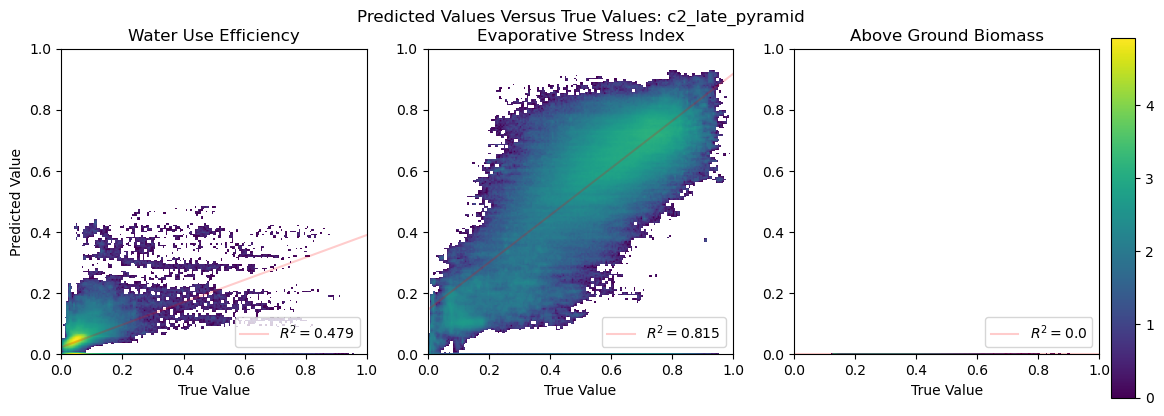

 - done with model


In [9]:
nbins = 200
idx = -1
for modelkey in runon:
    idx += 1
    fig, axes = plt.subplots(1, len(y_names), figsize=(12, 4))
    binned_y = []
    best_fits = []
    hist_y = []
    maxid = 0
    maxval = 0
    for k in range(len(y_names)):
        tempk = np.histogram2d(y_actual_through[k].flatten(), ops[modelkey][5][k].flatten(), bins=nbins, range=[[0, 1], [0, 1]])[0].transpose()
        #tempk[tempk == 1] = 2
        tempk = np.log10(tempk)
        hist_y.append(tempk)
        tempmax = np.max(tempk)
        print(tempmax) 
        if tempmax > maxval:
            maxid = k
            maxval = tempmax
    print(maxval)
    for k in range(len(y_names)):
        binned_y.append(axes[k].imshow(hist_y[k], vmin=0, vmax=maxval, origin='lower', extent=[0,1,0,1]))
        x_bf = np.linspace(0,1,100)
        y_bf = (x_bf * slopes[idx][k]) + (intercepts[idx][k]) 
        best_fits.append(axes[k].plot(x_bf, y_bf, label='$R^{2}=$' + str(round(r_values[idx][k], 3)), color="red", alpha=0.2))
        axes[k].legend(loc='lower right')
        #binned_y.append(axes[k].hist2d(y_actual_through[k].flatten(), predictions[i][j][k].flatten(), bins=200, norm="log", range=[[0, 1], [0, 1]]))
        axes[k].set(xlabel="True Value", title=y_names[k][0])
    
    axes[0].set(ylabel="Predicted Value")
    axes[1].set(title="Predicted Values Versus True Values: " + ops[modelkey][2] + "\n" + y_names[1][0])

    fig.subplots_adjust(right=0.99)
    cbar_ax = fig.add_axes([1, 0.005, 0.02, 0.9])
    fig.colorbar(binned_y[maxid], cax=cbar_ax)
    plt.savefig("predicted_actual_heatmaps/" + ops[modelkey][2] + "_log.png")
    plt.show()
    print(" - done with model")
